CIFAR-10 classification

Changelog

version 5
- Add data augmentation
- Add learning rate scheduler
- epochs = 40

In [21]:
import tensorflow as tf
import matplotlib.pyplot as plt

Dataset

In [22]:
dataset = tf.keras.datasets.cifar10
(x_train, y_train), (x_test, y_test) = dataset.load_data()

In [23]:
print(f"x_train:", "Shape", x_train.shape, ", Data Type", x_train.dtype, ", Min", x_train.min(), ", Max", x_train.max())
print(f"y_train:", "Shape", y_train.shape, ", Data Type", y_train.dtype, ", Min", y_train.min(), ", Max", y_train.max())
print(f"x_test:", "Shape", x_test.shape, ", Data Type", x_test.dtype, ", Min", x_test.min(), ", Max", x_test.max())
print(f"y_test:", "Shape", y_test.shape, ", Data Type", y_test.dtype, ", Min", y_test.min(), ", Max", y_test.max())

x_train: Shape (50000, 32, 32, 3) , Data Type uint8 , Min 0 , Max 255
y_train: Shape (50000, 1) , Data Type uint8 , Min 0 , Max 9
x_test: Shape (10000, 32, 32, 3) , Data Type uint8 , Min 0 , Max 255
y_test: Shape (10000, 1) , Data Type uint8 , Min 0 , Max 9


In [24]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [25]:
print(f"x_train:", "Shape", x_train.shape, ", Data Type", x_train.dtype, ", Min", x_train.min(), ", Max", x_train.max())
print(f"x_test:", "Shape", x_test.shape, ", Data Type", x_test.dtype, ", Min", x_test.min(), ", Max", x_test.max())

x_train: Shape (50000, 32, 32, 3) , Data Type float64 , Min 0.0 , Max 1.0
x_test: Shape (10000, 32, 32, 3) , Data Type float64 , Min 0.0 , Max 1.0


In [26]:
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

In [27]:
print(f"y_train:", "Shape", y_train.shape, ", Data Type", y_train.dtype, ", Min", y_train.min(), ", Max", y_train.max())
print(f"y_test:", "Shape", y_test.shape, ", Data Type", y_test.dtype, ", Min", y_test.min(), ", Max", y_test.max())

y_train: Shape (50000, 10) , Data Type float64 , Min 0.0 , Max 1.0
y_test: Shape (10000, 10) , Data Type float64 , Min 0.0 , Max 1.0


In [28]:
# Split train data to train/val data
x_train, x_val = x_train[:45000], x_train[45000:]
y_train, y_val = y_train[:45000], y_train[45000:]

In [29]:
print(f"x_train:", "Shape", x_train.shape, ", Data Type", x_train.dtype, ", Min", x_train.min(), ", Max", x_train.max())
print(f"y_train:", "Shape", y_train.shape, ", Data Type", y_train.dtype, ", Min", y_train.min(), ", Max", y_train.max())
print(f"x_val:", "Shape", x_val.shape, ", Data Type", x_val.dtype, ", Min", x_val.min(), ", Max", x_val.max())
print(f"y_val:", "Shape", y_val.shape, ", Data Type", y_val.dtype, ", Min", y_val.min(), ", Max", y_val.max())

x_train: Shape (45000, 32, 32, 3) , Data Type float64 , Min 0.0 , Max 1.0
y_train: Shape (45000, 10) , Data Type float64 , Min 0.0 , Max 1.0
x_val: Shape (5000, 32, 32, 3) , Data Type float64 , Min 0.0 , Max 1.0
y_val: Shape (5000, 10) , Data Type float64 , Min 0.0 , Max 1.0


In [30]:
# Data augmentation

def augment(image):
    # Pad the image with zeros on all sides
    image = tf.pad(image, [[4, 4], [4, 4], [0, 0]])

    # Randomly crop a 32x32 region from the padded image
    image = tf.image.random_crop(image, size=[32, 32, 3])

    # Randomly flip the image horizontally
    image = tf.image.random_flip_left_right(image)

    return image

In [31]:
# Create a dataset from numpy arrays

train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_dataset = train_dataset.map(lambda x, y: (augment(x), y))  # Apply data augmentation
train_dataset = train_dataset.batch(128)

In [32]:
val_dataset = tf.data.Dataset.from_tensor_slices((x_val, y_val))
val_dataset = val_dataset.batch(128)

In [33]:
test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_dataset = test_dataset.batch(128)

Model

In [34]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((32, 32, 3)),
    tf.keras.layers.Conv2D(16, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

In [35]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 156,074 (609.66 KB)

 Trainable params: 156,074 (609.66 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
boundaries = [7000, 12000]
values = [0.01, 0.001, 0.0001]
lr_schedule = tf.keras.optimizers.schedules.PiecewiseConstantDecay(boundaries, values)

In [37]:
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=lr_schedule, momentum=0.9),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy'])

In [38]:
epochs = 40
batch_size = 128
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epochs,
    # batch_size=batch_size
    )

Epoch 1/40
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.1956 - loss: 2.1612 - val_accuracy: 0.3862 - val_loss: 1.6957
Epoch 2/40
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.3948 - loss: 1.6576 - val_accuracy: 0.4380 - val_loss: 1.5446
Epoch 3/40
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.4554 - loss: 1.4896 - val_accuracy: 0.5282 - val_loss: 1.2994
Epoch 4/40
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.5079 - loss: 1.3603 - val_accuracy: 0.5698 - val_loss: 1.2136
Epoch 5/40
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5462 - loss: 1.2763 - val_accuracy: 0.6104 - val_loss: 1.1069
Epoch 6/40
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.5734 - loss: 1.1995 - val_accuracy: 0.6104 - val_loss: 1.0972
Epoch 7/40
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.5922 - loss: 1.1427 - val_accuracy: 0.6390 - val_loss: 1.0173
Epoch 8/40
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6093 - loss: 1.1022 - val_acc

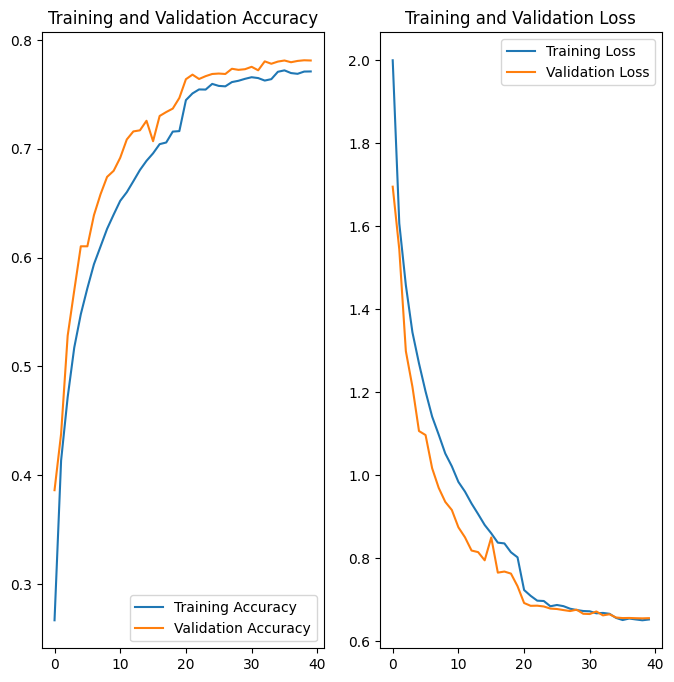

In [39]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [40]:
model.evaluate(test_dataset)

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7694 - loss: 0.6775


[0.6816182136535645, 0.7656000256538391]